In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
import stim
import sinter
import matplotlib.pyplot as plt
import os
from qecsim.lattice_surgery.circuit import surgery_circuit

'''
Sketches/Notes
'''

# 9 12 15
# 37 43 49
# M 3 14 27
#    TICK
#    CX rec[-1] 6 rec[-1] 7 rec[-1] 8 rec[-2] 6 rec[-2] 7 rec[-2] 8 rec[-3] 6 rec[-3] 7 rec[-3] 8

In [344]:
test_circuit = surgery_circuit(3, target_state_init="Z0", control_state_init="Z1", noise_depol_data_init = 0.0,noise_measure_flip = 0.0)
#test_circuit

In [345]:
'''
Define Test which checks the x basis measurement of the target
-> Should expect an always +1 measurement as c = 1, t = 0 -> c = 1, t = 1 

Just testing for d = 3 rund therefore some fixed values as qubit index
'''

def logical_x_mean_value(test_circuit : stim.Circuit, shot : int):

    #Define sampler and run samples
    sampler = test_circuit.compile_sampler()
    result = sampler.sample(shots = shot)

    logical_x_all_shots : list[list] = []

    for i in range(shot):
        logical_x_all_shots.append([result[i,-2], result[i,-5], result[i,-8]])

    # List where each resulting parity of each run is saved
    all_sums = []

    for i in range(shot):

        #Translating measurement values into int
        for elements in logical_x_all_shots[i]:
            joint_measurement = []
            if elements == False:
                joint_measurement.append(1)
            elif elements == True:
                joint_measurement.append(-1)

        #Current parity of given shot
        current_sums = 1

        for i in joint_measurement:
            current_sums = current_sums * i

        all_sums.append(current_sums)

    #Count the different results:
    count_off = 0
    count_on = 0

    for results in all_sums:
        if results == 1:
            count_off +=1
        elif results == -1:
            count_on +=1

    return(count_off / shot, count_on / shot)

In [358]:
logical_x_mean_value(test_circuit, 1000)

(0.487, 0.513)

In [27]:
task_noisy = [sinter.Task(
    circuit = surgery_circuit(
        distance = d,
        control_state_init = c_state,
        target_state_init = t_state,
        noise_depol_data_init = noise,
        noise_measure_flip = noise
    ),
    json_metadata={'p': noise, 'distance' : d, 'state_control' : c_state, 'state_target' : t_state}
    ) 
    for noise in [0.0001, 0.00025, 0.0005, 0.001, 0.010, 0.015, 0.1, 0.125, 0.2, 0.3, 0.35, 0.4, 0.45]
    for d in [3,5,7]
    for c_state in {"X+"}
    for t_state in {"X+"}
    ]

stats_noisy : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=task_noisy,
    decoders=['pymatching'],
    max_shots=100_000_0,
    max_errors=1000,
    print_progress=True
)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\f.spreemann\Documents\PYM STIM ENVIROMENT\.venv\Lib\site-packages\IPython\core\interactiveshell.py", line 3549, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\f.spreemann\AppData\Local\Temp\ipykernel_31716\2997922618.py", line 1, in <module>
    task_noisy = [sinter.Task(
                 ^^^^^^^^^^^^^
  File "C:\Users\f.spreemann\AppData\Local\Temp\ipykernel_31716\2997922618.py", line 2, in <listcomp>
    circuit = surgery_circuit(
              ^^^^^^^^^^^^^^^^
  File "<string>", line 34, in surgery_circuit
  File "<string>", line None, in split
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\f.spreemann\Documents\PYM STIM ENVIROMENT\.venv\Lib\site-packages\IPython\core\interactiveshell.py", line 2173, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^

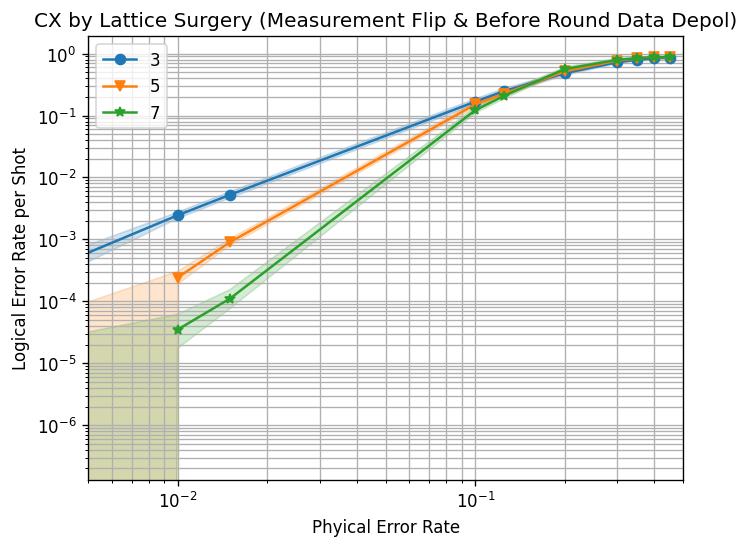

In [ ]:
fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats_noisy,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance']
)
ax.loglog()
ax.set_xlim(5e-3, 0.5)
ax.set_title("CX by Lattice Surgery (Measurement Flip & Before Round Data Depol)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger